# Environment Setup

## PIP

In [117]:
!pip install colour
!pip install matplotlib
!pip install pandas
!pip install utm
!pip install windrose




[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Imports

In [118]:

import math
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import pandas as pd
import utm
from itertools import product
from collections import defaultdict
import io
import pandas as pd
import pickle
import matplotlib.patches as patches
import glob
import os
import datetime
import windrose
from copy import deepcopy

## Functions

In [119]:
def windAnalysis(heading,windDirection, windSpeed):
    newWindDirections = []
    newWindSpeeds = []
    for i in range(0,windDirection.__len__()):
        if(windDirection[i] == 'nan' or heading[i] == 'NaN'):
            a = 1 
        elif(float(windDirection[i]) < 0):
            windScaled = 360+float(windDirection[i])
            windMagnetic = windScaled + float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))
        elif(float(windDirection[i]) > 0):
            windMagnetic = float(windDirection[i]) +float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))

    for i in range(0,windSpeed.__len__()):
        if(windSpeed[i] == 'nan'):
            a = 1 
        elif(float(windSpeed[i]) < 0):
            newWindSpeeds.append(float(windSpeed[i]))
        elif(float(windSpeed[i]) > 0):
            newWindSpeeds.append(float(windSpeed[i]))
        

    ## Calculate Average Wind Direction and Speed and put in a bin
    totalDirection = 0
    totalSpeed = 0
    for i in range(0,newWindDirections.__len__()):
        totalDirection += newWindDirections[i]

    for i in range(0,newWindSpeeds.__len__()):
        totalSpeed += float(newWindSpeeds[i])


    avgDirection = totalDirection/newWindDirections.__len__() 
    avgSpeed = totalSpeed/newWindSpeeds.__len__()
    if math.isnan(avgDirection):
        avgDirection = 0
    return [avgDirection,avgSpeed]

def windBins(dfArray):
    directionBins = [[] for _ in range(361)]
    speedBins = [[] for _ in range(50)]
    for i in range(0,90):
        currdf = dfArray[i]
        if (' WndDr' in currdf) and (' WndSpd' in currdf) and (' HDG' in currdf):
            averages = windAnalysis(currdf[' HDG'],currdf[' WndDr'],currdf[' WndSpd'])
            destinationBin = int(math.floor(averages[0]))
            speedBin = int(math.floor(averages[1]))
            # print(math.floor(averages[0]))
            # print(destinationBin, "--" , i,"speed",speedBin )
            directionBins[destinationBin].append(i)
            speedBins[speedBin].append(i)
    return (directionBins,speedBins)




def summaryStatistics(descent,summaryTarget:str,file,currFlight,descentNum):
    meanDescentRate = np.mean(pd.to_numeric(descent[summaryTarget]))
    medianDescentRate = np.median(pd.to_numeric(descent[summaryTarget]))
    stdDescentRate = np.std(pd.to_numeric(descent[summaryTarget]))
    maxDescentRate = np.max(pd.to_numeric(descent[summaryTarget]))
    minDescentRate = np.min(pd.to_numeric(descent[summaryTarget]))
    results = (float(meanDescentRate), float(medianDescentRate), float(stdDescentRate), float(maxDescentRate), float(minDescentRate))
    file.write("{}, {}, {},{},{},{},{}\n".format(currFlight,descentNum,results[0],results[1],results[2],results[3],results[4]))
    file.flush()


def distanceImageVelocity(descent, convert):

    if ' GndSpd' in descent and ' HDG' in descent:

        index = 0
        for i in range(len(descent)):
            if descent['AltAGL'][i] < 10:
                index = i
                break

        totalX_nm = 0.0
        totalY_nm = 0.0

        for i in range(0, index):

            s1 = float(descent[' GndSpd'][i])
            s2 = float(descent[' GndSpd'][i+1])

            if convert:
                s1 *= 1.94384
                s2 *= 1.94384

            avgS = (s1 + s2) / 2

            heading_deg = float(descent[' HDG'][i])
            heading_rad = math.radians(heading_deg)

            d_nm = avgS / 3600.0

            dx = d_nm * math.cos(heading_rad)
            dy = d_nm * math.sin(heading_rad)

            totalX_nm += dx
            totalY_nm += dy

        # Distance (magnitude)
        distance_nm = math.sqrt(totalX_nm**2 + totalY_nm**2)

        # Direction (bearing)
        bearing_rad = math.atan2(totalY_nm, totalX_nm)
        bearing_deg = (math.degrees(bearing_rad) + 360) % 360

        print("Distance:", distance_nm, "NM")
        print("Bearing:", bearing_deg, "deg")

        return [distance_nm, bearing_deg]
    

def utilizeModelData(useManual:bool = False):
    filePath = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/FollowCoords2--Turbulence Experiments 2026-02-14 14:10:32.404221"
    filePath2 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/Roll1--Turbulence Experiments 2026-02-13 13:03:32.478263/1_Roll1--Turbulence Experiments.csv"
    filePath3 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest1--Turbulence Experiments 2026-03-20 09:53:39.848992/{}_RecTest1--Turbulence Experiments.csv"
    filePath4 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest2--Turbulence Experiments 2026-03-20 09:59:21.064022/{}_RecTest2--Turbulence Experiments.csv"
    filePath5 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest3--Turbulence Experiments 2026-03-20 10:09:38.439818/{}_RecTest3--Turbulence Experiments.csv"
    filePath6 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest4--Turbulence Experiments 2026-03-20 10:16:14.758129/{}_RecTest4--Turbulence Experiments.csv"
    showcaseRun = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest6--Turbulence Experiments 2026-03-20 10:32:46.050711/{}_RecTest6--Turbulence Experiments.csv"
    showcaseRun2= "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest7--Turbulence Experiments 2026-03-20 10:36:47.246532/{}_RecTest7--Turbulence Experiments.csv"
    comparisonRuns = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ComparisonRuns--Turbulence Experiments 2026-03-13 17:00:07.067204/{}_ComparisonRuns--Turbulence Experiments.csv"
    ex2 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ex2--turbulence experiments 2026-04-13 01:20:57.181772/{}_ex2--turbulence experiments.csv"
    ex6 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/Ex6--turbulence experiments 2026-04-13 13:00:40.017013/{}_Ex6--turbulence experiments.csv"
    combinedAnalysis = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/CombinedAnalysis--turbulence experiments 2026-06-05 10:05:24.166731/{}_CombinedAnalysis--turbulence experiments.csv"
    manualControl1 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ManualControl-1--turbulence experiments 2026-04-23 16:20:19.558488/{}_ManualControl-1--turbulence experiments.csv"
    modelData = [[]]
    for x in range (1,100):
        try:
            # data = pd.read_csv('/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ComparisonRuns--Turbulence Experiments 2026-03-13 17:00:07.067204/{}_ComparisonRuns--Turbulence Experiments.csv'.format(x))
            # data = pd.read_csv(comparisonRuns.format(x))
            # data = pd.read_csv(showcaseRun.format(x))
            data = pd.read_csv(ex6.format(x))
            if (useManual):
                data = pd.read_csv(manualControl1.format(x))

            modelData[0].append(data)
        except FileNotFoundError:
            print("{} Files Loaded".format(x-1))
            return modelData
            break
        else:
            # Continue Loop
            continue


## Global Variables

In [120]:
directionBins = [[] for _ in range(361)]
speedBins = [[] for _ in range(50)]
colors =["red","green","blue","purple","orange","black","yellow","cyan","magenta","brown","pink","gray","olive","lime","teal","navy"]

# Data Ingestion

In [121]:
aircraft = "Cessna_172S_flight_"
dfArray = []
for x in range(1,101):
    new_df = pd.read_csv(f'../../Project_Data/Empirical_Data/GATS_Dataset/{aircraft}{x}.csv')
    dfArray.append(new_df)
dfArray[0].head()
dfArray.__len__()

100

# Descent Population from Empirical

In [122]:
descentArray = [[] for _ in range(0,dfArray.__len__())]
headingAtLanding = []
fieldElevation = []
magneticVariation = []
crossWindComponent = []
minStep = 50
maxStep = 500
excludedDescents = []

def checkExcluded(x1,x2,excludedDescents):
    for descent in excludedDescents:
        if(x1>= descent[0] and x1 <= descent[1] 
           or
           x2>= descent[0] and x2 <= descent[1]
           or descent[0]>= x1 and descent[0] <= x2 and descent[1]>= x1 and descent[1] <= x2):
            return True
    return False
x = 0
for currdf in dfArray:
    # currdf = dfArray[x]
    excludedDescents = []
    if ' WndDr' in currdf and ' WndSpd' in currdf: 
        for stepCount in range(minStep,maxStep):
            step = stepCount
            altitudeDeltaThreshold = 800

            for xInner in range(0, currdf.__len__()-step, step):
                storageCount = 0
                x1 = xInner
                x2 = xInner+step
                delta = currdf['AltAGL'][x1] - currdf['AltAGL'][x2]
                if delta >= altitudeDeltaThreshold and currdf['AltAGL'][x2] <= 0 and currdf['AltAGL'][x1] > 0.0:
                    # print(f"Found Descent in flight {x}: From {currdf['AltAGL'][x1]} ft AGL to {currdf['AltAGL'][x2]} ft AGL over {x2-x1} data points.")
                    if(currdf['AltAGL'][x1] <= 1020 and currdf['AltAGL'][x1] >=1000):
                        # print(f"Found Descent in flight {x}: From {currdf['AltAGL'][x1]} ft AGL to {currdf['AltAGL'][x2]} ft AGL over {x2-x1} data points.")
                        excludeDescent = checkExcluded(x1,x2,excludedDescents)
                        if(excludeDescent):                
                            ## Do Nothing 
                            print("descent excluded: {} to {} in flight {}".format(x1,x2,x))
                        elif(not excludeDescent):
                            newDataFrame = pd.DataFrame(currdf[:][x1:x2]).reset_index()
                            descentArray[x].append(newDataFrame)
                            headingAtLanding.append(currdf[' HDG'][x2]) #Heading at Landing
                            fieldElevation.append(currdf[' AltMSL'][x2]) #Field Elevation at Landing
                            magneticVariation.append(currdf[' MagVar'][x2])
                            excludedDescents.append([x1,x2])
                            currFlight = x 

                            # summaryStatistics(newDataFrame,' Pitch',filePitch,currFlight,excludedDescents.__len__())
                            # summaryStatistics(newDataFrame,' Roll',fileRoll,currFlight,excludedDescents.__len__())
                            # summaryStatistics(newDataFrame,' CAS',fileCAS,currFlight,excludedDescents.__len__())
                            # summaryStatistics(newDataFrame,' IAS',fileIAS,currFlight,excludedDescents.__len__())
                            # summaryStatistics(newDataFrame,' VSpd',fileVspd,currFlight,excludedDescents.__len__())
                            print("Descent added to exclusion between: {} to {} in flight {}".format(x1,x2,x))
                            
                        ##Clearning Descent from array

                        # for i in range(x1,x2+1):
                        #     currdf['AltAGL'][i] = 0

                        # crossWindComponent.append(currdf[' WndSpd'][x2] * math.sin(currdf[' HDG'][x2]-currdf[' WndDr'][x2])) #Crosswind Component at Landing
                        storageCount+=1
    x+=1

        
        # descentArray[0].head()
        # x1 = xInner
        # x2 = xInner+step

descentArray.__len__()

Descent added to exclusion between: 3738 to 4005 in flight 0
Descent added to exclusion between: 2037 to 2328 in flight 0
Descent added to exclusion between: 3640 to 4004 in flight 1
Descent added to exclusion between: 4032 to 4368 in flight 2
Descent added to exclusion between: 4296 to 4654 in flight 4
Descent added to exclusion between: 2484 to 2760 in flight 6
descent excluded: 2485 to 2840 in flight 6
descent excluded: 2484 to 2898 in flight 6
Descent added to exclusion between: 5292 to 5544 in flight 7
descent excluded: 5292 to 5586 in flight 7
descent excluded: 5296 to 5627 in flight 7
descent excluded: 5295 to 5648 in flight 7
descent excluded: 5292 to 5670 in flight 7
Descent added to exclusion between: 4708 to 4922 in flight 8
Descent added to exclusion between: 4371 to 4512 in flight 9
descent excluded: 4370 to 4560 in flight 9
Descent added to exclusion between: 4176 to 4524 in flight 11
Descent added to exclusion between: 4556 to 4824 in flight 12
Descent added to exclusion

100

# Experiment Setup Files

In [123]:
# Creating Experiment Setup Files
import csv
file = open("../../Project_Code/Python3Model/src/experiments/weather_files/experimentSetup.csv","w")

csv_writer = csv.writer(file)

csv_writer.writerow([
  "turbulence experiments",
  "Cognitive Delay",
  "reference_latitude",
  "reference_longitude",
  "reference_radial",
  "distance",
  "altitude_agl",
  "x_velocity",
  "y_velocity",
  "z_velocity",
  "p_rotation",
  "q_rotation",
  "r_rotation",
  "heading",
  "wind_altitude",
  "wind_direction",
  "wind_speed",
  "turbulence_level",
  "velocity_initial",
  "fuel_level",
  "flaps"
])

csv_writer.writerow(
    [
  "null",
  "null",
  "null",
  "null",
  "null",
  "null",
  "null",
  "sim/flightmodel/position/local_vx",
  "sim/flightmodel/position/local_vy",
  "sim/flightmodel/position/local_vz",
  "sim/flightmodel/position/P",
  "sim/flightmodel/position/Q",
  "sim/flightmodel/position/R",
  "sim/flightmodel/position/q",
  "sim/weather/wind_altitude_msl_m[0]",
  "sim/weather/wind_direction_degt[0]",
  "sim/weather/wind_speed_kt[0]",
  "sim/weather/turbulence[0]",
  "sim/flightmodel/position/local_vz",
  "sim/flightmodel/weight/m_fuel",
  "sim/flightmodel2/controls/flap1_deploy_ratio"
]
)

def getAverageWindDirection(landing):
    total = 0
    for i in range(0,landing.__len__()):
        if ' WndDr' in landing:
            wd_rel = float(landing[' WndDr'][i])
            hdg_mag = float(landing[' HDG'][i])
            mag_var = float(landing[' MagVar'][i])  # east positive

            hdg_true = hdg_mag + mag_var
            wd_true = (wd_rel + hdg_true) % 360

            total += wd_true
            # # total+=float(landing[' WndDir'][i])
            # total+=float(landing[' WndDr'][i])
    return total/landing.__len__()

def getAverageWindSpeed(landing):
    total = 0
    for i in range(0,landing.__len__()):
        if ' WndSpd' in landing:
            # total+=float(landing[' WndDir'][i])
            total+=float(landing[' WndSpd'][i])
    return total/landing.__len__()


def getInitialVelocity(landing):
    if ' GndSpd' in landing:
        return landing[' GndSpd'][0]
    
def getInitialAltitudeAGL(landing):
    if 'AltAGL' in landing:
        return landing['AltAGL'][0]

def getInitialHeading(landing):
    if ' HDG' in landing:
        return landing[' HDG'][0]
    
def getAverageDescentRate(landing):
    if 'AltAGL' in landing:
        return ((landing['AltAGL'][landing.__len__()-1] - landing['AltAGL'][0])/landing.__len__()) * 60


count = 0
for descent in descentArray:
    for landing in descent:
        result = distanceImageVelocity(landing,False)
        cognitive_delay = 0.15
        lat = 39.875027
        long = -104.696482
        radial = 359
        distance = result[0]
        altitude_agl = getInitialAltitudeAGL(landing)-200
        x_velocity = 0
        y_velocity = 0
        z_velocity = 0
        p_rotation = 0
        q_rotation = 0
        r_rotation = 0
        heading = 179
        wind_altitude = 0
        wind_direction = getAverageWindDirection(landing)
        wind_speed = getAverageWindSpeed(landing) 
        turbulence_level = 0
        velocity_initial = getInitialVelocity(landing)
        fuel_level = 20
        average_descent_rate = getAverageDescentRate(landing)
        flaps = 0
        
        csv_writer.writerow([
            count,
            cognitive_delay,
            lat,
            long,
            radial,
            distance,
            altitude_agl,
            x_velocity,
            y_velocity,
            z_velocity,     
            p_rotation,
            q_rotation,
            r_rotation,
            heading,
            wind_altitude,
            wind_direction,
            wind_speed,
            turbulence_level,
            velocity_initial,
            fuel_level,
            flaps
        ])
        count+=1
file.close()

Distance: 2.982775015505134 NM
Bearing: 224.91832666344888 deg
Distance: 0.43825274095345623 NM
Bearing: 252.01759852017818 deg
Distance: 4.587896092308574 NM
Bearing: 235.1827323865361 deg
Distance: 4.380953135736078 NM
Bearing: 245.20885637268324 deg
Distance: 3.033257612197004 NM
Bearing: 44.08955265237853 deg
Distance: 3.3029707342027272 NM
Bearing: 174.54898689011907 deg
Distance: 4.029740134831729 NM
Bearing: 225.9202967652078 deg
Distance: 3.243720716265803 NM
Bearing: 136.07457866708512 deg
Distance: 2.9827384761555726 NM
Bearing: 175.33875270026238 deg
Distance: 3.1838140409859252 NM
Bearing: 359.78451021881483 deg
Distance: 3.1047825844102714 NM
Bearing: 266.20664045397785 deg
Distance: 3.2862166316594497 NM
Bearing: 0.3010018768545706 deg
Distance: 0.21903471344982575 NM
Bearing: 323.61801483056377 deg
Distance: 2.830635333066114 NM
Bearing: 182.79299311140232 deg
Distance: 3.027102892574508 NM
Bearing: 174.72550883257213 deg
Distance: 0.7734407676053833 NM
Bearing: 295.8388

# Model Data Ingestion

In [124]:
modelDescentArray = utilizeModelData()

17 Files Loaded


# Manual Data Ingestion

In [125]:
manualDescentArray = utilizeModelData(True)

4 Files Loaded


# Plotting All Arrays

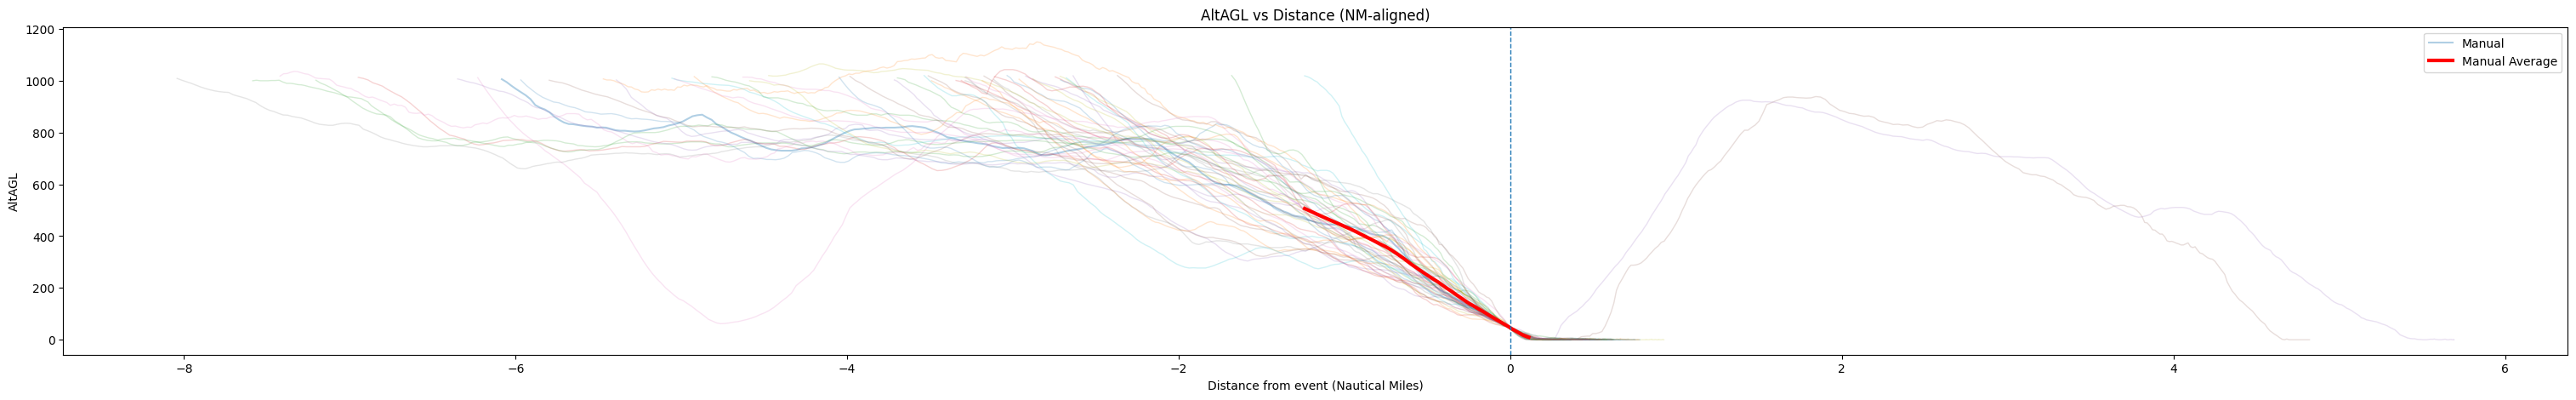

In [140]:
def environmentalFilter(df, max_alt_at_1nm=500, dt=0.1):
    """
    Returns True if aircraft is below max_alt_at_1nm feet
    at approximately 1 NM before touchdown/runway.

    Assumes:
    - AltAGL is in feet
    - GndSpd is in knots
    - dt is seconds per row if no time column is available
    """

    if "AltAGL" not in df.columns or " GndSpd" not in df.columns:
        return False

    alt = pd.to_numeric(df["AltAGL"], errors="coerce").to_numpy()
    gs = pd.to_numeric(df[" GndSpd"], errors="coerce").to_numpy()

    valid = np.isfinite(alt) & np.isfinite(gs)
    if valid.sum() < 2:
        return False

    alt = alt[valid]
    gs = gs[valid]

    # Find touchdown / runway point as lowest valid altitude near end
    touchdown_index = np.nanargmin(alt)

    # Distance traveled per sample in nautical miles
    # knots = NM/hour, so NM per sample = knots * seconds / 3600
    dist_per_step_nm = gs * dt / 3600.0

    # Walk backward from touchdown, accumulating distance
    cumulative_back_nm = np.cumsum(dist_per_step_nm[:touchdown_index + 1][::-1])

    # Find point closest to 1 NM before touchdown
    idx_back = np.argmin(np.abs(cumulative_back_nm - 1.0))
    one_nm_index = touchdown_index - idx_back

    alt_at_1nm = alt[one_nm_index]

    return True
        
    
    # # Wind Direction on Landing is Within 30 Degrees of landing direction
    # if ' WndDr' in df or ' Pitch' in df:
    #     # wd_rel = df[' WndDr']
    #     # # hdg_mag = df[' HDG']
    #     # mag_var = df[' MagVar']  # east positive

    #     # hdg_true = hdg_mag + mag_var
    #     # wd_true = (wd_rel + hdg_true) % 360

    #     return True

    # if ' WndSpd' in df and ' WndDr' in df:
    #     return (df[' WndSpd'] > 10) & (df[' WndDr'] > 180)
    # return pd.Series([False] * len(df))

# -----------------------------
# COLUMN EXTRACTION
# -----------------------------
def get_array(obj, column):
    if hasattr(obj, "columns"):
        return np.array(obj[column], dtype=float)
    if isinstance(obj, dict):
        return np.array(obj[column], dtype=float)
    return np.array(obj, dtype=float)


# -----------------------------
# FLATTEN INPUT STRUCTURE
# -----------------------------
def flatten(data):
    for item in data:
        if isinstance(item, list):
            yield from flatten(item)
        else:
            yield item


# -----------------------------
# FIND EVENT INDEX
# -----------------------------
# def find_event_index(df, column="AltAGL", threshold=100):
#     arr = get_array(df, column)
#     idx = np.where(arr < threshold)[0]
#     return idx[0] if len(idx) > 0 else None

def find_event_index(
    df,
    column="AltAGL",
    threshold=100,
    alt_scale_factor=1.0
):

    arr = get_array(df, column)

    # Apply altitude scaling BEFORE threshold detection
    arr = arr * alt_scale_factor

    idx = np.where(arr < threshold)[0]

    return idx[0] if len(idx) > 0 else None


# -----------------------------
# BUILD NAUTICAL MILE DISTANCE AXIS
# -----------------------------
def build_nm_axis(df, ref_index, dt=1.0, speed_scale_factor=1.0):
    """
    Builds distance axis in nautical miles.

    speed_scale_factor converts input speed units to knots.
    """

    speed = get_array(df, " GndSpd")

    # Convert to knots if needed
    speed = speed * speed_scale_factor

    # knots -> NM/sec
    nm_per_sec = speed / 3600.0

    # integrate distance
    nm = np.cumsum(nm_per_sec * dt)

    # align to reference point
    nm = nm - nm[ref_index]

    return nm

# -----------------------------
# GET SIGNAL
# -----------------------------
def get_series(df, column):
    return get_array(df, column)

# -----------------------------
# MAIN PLOT FUNCTION (NM X-AXIS)
# -----------------------------
def plot_aligned_group_nm(
    data_list,
    column,
    event_col="AltAGL",
    threshold=100,
    dt=1.0,
    scale_factor=1.0,
    speed_scale_factor=1.0
):

    plt.figure(figsize=(18, 5))

    for df in flatten(data_list):

        try:
            ref_index = find_event_index(df, event_col, threshold)
            if ref_index is None:
                continue

            y = get_series(df, column)

            # ---- APPLY UNIT CONVERSION HERE ----
            y = y * scale_factor

            x = x = build_nm_axis(
    df,
    ref_index,
    dt=dt,
    speed_scale_factor=speed_scale_factor
)

            n = min(len(x), len(y))
            x, y = x[:n], y[:n]

            plt.plot(x, y, alpha=0.25, linewidth=1)

        except Exception as e:
            print("Skipping run:", e)

    plt.axvline(0, color="black", linestyle="--")
    plt.xlabel("Distance from event (Nautical Miles)")
    plt.ylabel(column)
    plt.title(f"{column} vs Distance (NM-aligned)")
    plt.show()


# -----------------------------
# SINGLE RUN VERSION
# -----------------------------
def plot_aligned_run_nm(df, column, event_col="AltAGL", threshold=100, dt=1.0):
    ref_index = find_event_index(df, event_col, threshold)
    if ref_index is None:
        print("No event found")
        return

    y = get_series(df, column)
    x = build_nm_axis(df, ref_index, dt=dt)

    n = min(len(x), len(y))
    plt.plot(x[:n], y[:n])

    plt.axvline(0, color="black", linestyle="--")
    plt.xlabel("Distance from event (Nautical Miles)")
    plt.ylabel(column)
    plt.title(column)
    plt.show()


def plot_multiple_groups_nm(
    data_groups,
    column,
    event_col="AltAGL",
    threshold=100,
    dt=1.0,
    scale_factors=None,
    speed_scale_factors=None,
    labels=None,
    lineStyles=None,
    averageColors=None
):

    # defaults
    if scale_factors is None:
        scale_factors = [1.0] * len(data_groups)

    if speed_scale_factors is None:
        speed_scale_factors = [1.0] * len(data_groups)

    if labels is None:
        labels = [f"Group {i}" for i in range(len(data_groups))]
    if lineStyles is None:
        lineStyles = [f"--" for i in range(len(data_groups))]

    plt.figure(figsize=(38, 5))

    for group, scale, speed_scale, label, lineStyle,avgColor in zip(
        data_groups,
        scale_factors,
        speed_scale_factors,
        labels,
        lineStyles,
        averageColors
    ):

        first_line = True

        all_traces = []

        for df in flatten(group):
            if environmentalFilter(df) is True: 
                try:
                    ref_index = find_event_index(
                        df,
                        event_col,
                        threshold,
                        scale
                    )

                    if ref_index is None:
                        continue

                    # Y variable scaling
                    y = get_series(df, column) * scale

                    # Distance axis
                    x = build_nm_axis(
                        df,
                        ref_index,
                        dt=dt,
                        speed_scale_factor=speed_scale
                    )

                    n = min(len(x), len(y))

                    all_traces.append((x, y))


                    if first_line:
                        plt.plot(
                            x[:n],
                            y[:n],
                            alpha=0.35,
                            linewidth=1.5,
                            label=label,
                            linestyle=lineStyle
                        )
                        first_line = False
                    else:
                        plt.plot(
                            x[:n],
                            y[:n],
                            alpha=0.2,
                            linewidth=1,
                            linestyle=lineStyle
                        )
                except Exception as e:
                    print("Skipping run:", e)
        if all_traces:
                xmin = max(trace[0].min() for trace in all_traces)
                xmax = min(trace[0].max() for trace in all_traces)

                common_x = np.linspace(xmin, xmax, 500)

                interpolated = []

                for x, y in all_traces:
                    interp_y = np.interp(common_x, x, y)
                    interpolated.append(interp_y)

                mean_y = np.mean(interpolated, axis=0)

                plt.plot(
                    common_x,
                    mean_y,
                    color=avgColor,
                    linewidth=3,
                    label=f"{label} Average"
                )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Distance from event (Nautical Miles)")
    plt.ylabel(column)
    plt.title(f"{column} vs Distance (NM-aligned)")
    # plt.xlim(-2, 0.5)
    plt.legend()
    plt.show()

plot_multiple_groups_nm(
    [
    #     deepcopy(manualDescentArray), 
    #  deepcopy(modelDescentArray)\
     deepcopy(descentArray)
     ],
    column="AltAGL",
    threshold=50,
    scale_factors=[
        # 3.28084,
        # 3.28084, 
        1.0
        ],
    speed_scale_factors=[
        # 1.94384, 1.94384, 
        1.0],
    labels=["Manual", "Model", "Empirical"],
    lineStyles=["-", "--", "-."],
    averageColors=["red", "blue", "green"]
)

# Error Metrics

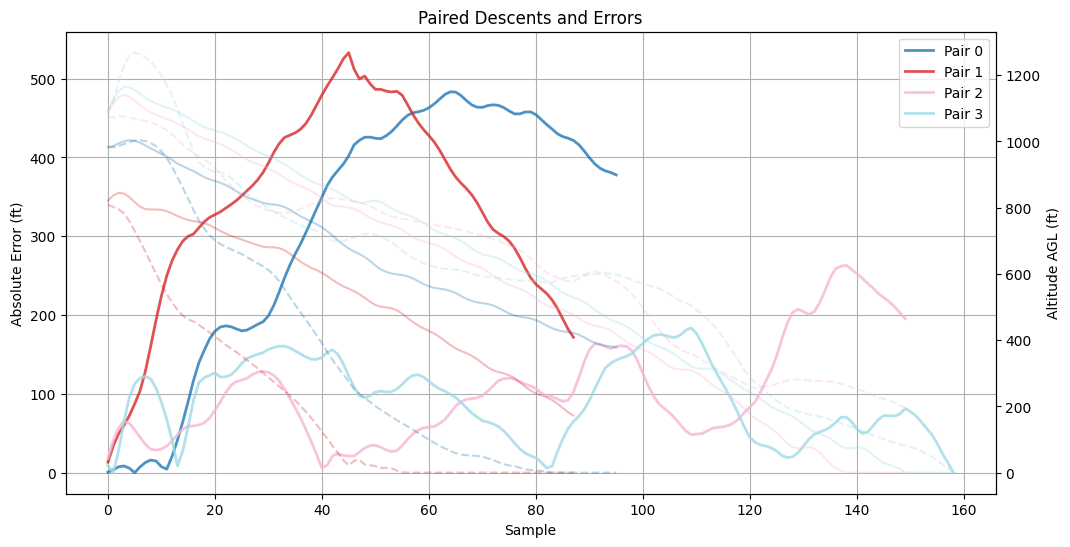

In [138]:
modelDescents = flatten(modelDescentArray)
manualDescents = flatten(manualDescentArray)
column = 'AltAGL'
finalComparison = [[],[]]
for descent,descent2 in zip(modelDescents,manualDescents):
    ref_index = find_event_index(descent, column, 0)
    # Y variable scaling
    y = get_series(descent, column) * 3.28084
    # Distance axis
    x = build_nm_axis(
        descent,
        ref_index,
        dt=1,
        speed_scale_factor=3.28084
    )
    n = min(len(x), len(y))
    finalComparison[0].append(y)

    ref_index = find_event_index(descent2, column, 0)
    # Y variable scaling
    y2 = get_series(descent2, column) * 3.28084
    # Distance axis
    x2 = build_nm_axis(
        descent2,
        ref_index,
        dt=1,
        speed_scale_factor=3.28084
    )
    n2 = min(len(x2), len(y2))
    finalComparison[1].append(y2)

# for x in range (0,finalComparison[0].__len__()):
#     a = finalComparison[0][x]
#     b = finalComparison[1][x]

#     n = min(len(a), len(b))

#     abs_error = np.abs((a[:n] - b[:n]))
#     # abs_error = (finalComparison[0] - finalComparison[1]).abs()
#     print("Absolute Errors:", abs_error.tolist())

# for i in range(len(finalComparison[0])):
#     a = np.asarray(finalComparison[0][i])
#     b = np.asarray(finalComparison[1][i])

#     n = min(len(a), len(b))

#     abs_error = np.abs(a[:n] - b[:n])

#     plt.figure(figsize=(10, 4))
#     plt.plot(abs_error)
#     plt.title(f"Descent {i} Absolute Error")
#     plt.xlabel("Sample")
#     plt.ylabel("Error (ft)")
#     plt.grid(True)
#     plt.show()


## PLOTTING ERROR
# plt.figure(figsize=(12, 6))

# for i in range(len(finalComparison[0])):
#     a = np.asarray(finalComparison[0][i])
#     b = np.asarray(finalComparison[1][i])

#     n = min(len(a), len(b))

#     abs_error = np.abs(a[:n] - b[:n])

#     plt.plot(abs_error, alpha=0.5, label=f"Descent {i}")

# plt.title("Absolute Error Across All Descents")
# plt.xlabel("Sample")
# plt.ylabel("Error (ft)")
# plt.grid(True)

# # Optional if there are only a few descents
# plt.legend()

# plt.show()

## PLotting Squared Error:
# plt.figure(figsize=(12, 6))

# for i in range(len(finalComparison[0])):
#     a = np.asarray(finalComparison[0][i])
#     b = np.asarray(finalComparison[1][i])

#     n = min(len(a), len(b))

#     squared_error = (a[:n] - b[:n]) ** 2

#     plt.plot(squared_error, alpha=0.5, label=f"Descent {i}")

# plt.title("Squared Error Across All Descents")
# plt.xlabel("Sample")
# plt.ylabel("Squared Error (ft²)")
# plt.grid(True)
# plt.show()

## TWO AXIS ERROR
# fig, ax1 = plt.subplots(figsize=(12, 6))
# ax2 = ax1.twinx()

# for i in range(len(finalComparison[0])):
#     a = np.asarray(finalComparison[0][i]) # Model
#     b = np.asarray(finalComparison[1][i]) # Manual

#     n = min(len(a), len(b))

#     abs_error = np.abs(a[:n] - b[:n])

#     # Error traces
#     ax1.plot(abs_error, alpha=0.4)

#     # Model/manual descents
#     ax2.plot(a[:n], alpha=0.15, linestyle='-',label='Model') # Model
#     ax2.plot(b[:n], alpha=0.15, linestyle='--',label='Manual')

# ax1.set_title("Absolute Error with Model and Manual Descents")
# ax1.set_xlabel("Sample")
# ax1.set_ylabel("Absolute Error (ft)")
# ax2.set_ylabel("Altitude AGL (ft)")

# ax1.grid(True)
# plt.legend()
# plt.show()


## TWO AXIS ERROR PAIRED COLORS
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

colors = plt.cm.tab20(np.linspace(0, 1, len(finalComparison[0])))

for i, color in enumerate(colors):
    a = np.asarray(finalComparison[0][i])
    b = np.asarray(finalComparison[1][i])

    n = min(len(a), len(b))

    abs_error = np.abs(a[:n] - b[:n])

    # Error
    ax1.plot(
        abs_error,
        color=color,
        linewidth=2,
        alpha=0.8,
        label=f"Pair {i}"
    )

    # Model
    ax2.plot(
        a[:n],
        color=color,
        linestyle='-',
        alpha=0.3
    )

    # Manual
    ax2.plot(
        b[:n],
        color=color,
        linestyle='--',
        alpha=0.3
    )

ax1.set_xlabel("Sample")
ax1.set_ylabel("Absolute Error (ft)")
ax2.set_ylabel("Altitude AGL (ft)")
ax1.set_title("Paired Descents and Errors")
ax1.grid(True)
ax1.legend()
plt.show()


## PLOTT
# for i in range(len(finalComparison[0])):
#     a = np.asarray(finalComparison[0][i])
#     b = np.asarray(finalComparison[1][i])

#     n = min(len(a), len(b))

#     plt.figure(figsize=(10, 5))
#     plt.plot(a[:n], label="Model")
#     plt.plot(b[:n], label="Manual")

#     plt.title(f"Descent {i}")
#     plt.xlabel("Sample")
#     plt.ylabel("Altitude AGL (ft)")
#     plt.grid(True)
#     plt.legend()
#     plt.show()



## Empirical Descent provided starting conditions -  Model vs Manual (vs Empirical)